# Figure 5f–j, and Figure S11 — sensory modules of PSI-IhN postsynaptic neurons

**This notebook produces main-figure panels as well as supplement.** Every figure it makes,
in cell order:

| Cell | Output | Panel |
| --- | --- | --- |
| 3 (`FIGURE 1`) | `violin_<tag>__axon_pre.svg` — selectivity vs number of PSI-IhN synapses, one per population | **Fig. S11a–e** |
| 4 (`FIGURE 2`) | `ecdf_target_sensory_fraction__axon_pre.svg` — cumulative selectivity, all populations | same quantity as **Fig. 5c** (the clean version is `figure5c_homotypic_selectivity_ecdf.ipynb`) |
| 5 (`FIGURE 3`) | `<tag>__selectivity__axon_pre.svg` — selective vs non-selective share | **Fig. S11f–j** |
| 5 (`FIGURE 3`) | `<tag>__composition__axon_pre.svg` — **sensory module breakdown among the selective neurons** | **Fig. 5f–j** |
| 6 (`FIGURE 4`) | `post_syn_sensory_composition__axon_pre_0910.svg` — stacked sensory composition | same quantity as **Fig. 5e** (clean version in `figure5de_...ipynb`) |

A neuron is **selective** (i.e. belongs to a sensory module) when one sensory subtype
supplies >50% of its sensory input. The 5f–j pies show the module breakdown of those
neurons only, which is why their *n* is smaller than the S11a–e *n*:

| Population | S11a–e *n* (all) | 5f–j *n* (selective) |
| --- | --- | --- |
| PSI-IhN^Aδ-HTMR | 392 | 254 |
| Islet-PSI-IhN^C-HTMR/Heat | 159 | 121 |
| Islet-PSI-IhN^C-LTMR | 85 | 66 |
| Islet-PSI-IhN^Aδ-LTMR | 519 | 426 |
| PSI-IhN^Aβ-LTMR | 554 | 420 |
| **total** | **1709** | **1287** (75.3%) |

Both columns reproduce their published legends exactly. Note the Results quote 77.1%
selective over "1,553 dorsal horn neurons", a different denominator from the 1,709
axon-presynaptic *connections* used here.

Outputs are written to `figureS11_outputs/`. **Runs offline — no CAVE access.**

---


In [11]:
# ============================================================
# CELL 0: Imports + config
# ============================================================
import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Optional

# ----------------------------
# Paths (edit these if needed)
# ----------------------------
CSV_IN = "../data/psi_ihn_partners_filtered_gt400.csv"
FEATHER_DIR = Path("../data/psi_ihn_postsynaptic_feather")
OUT_DIR = "figureS11_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("CSV exists:      ", os.path.exists(CSV_IN), "->", CSV_IN)
print("FEATHER_DIR exists:", FEATHER_DIR.exists(), "->", FEATHER_DIR)

# ----------------------------
# Which partner "kind" to analyze
#   "axon_pre"     -> matches axodendritic_post_sensory_analysis_figure5.ipynb
#   "dendrite_pre" -> matches axodendritic_post_sensory_analysis_dendrite_only_figure5.ipynb
# ----------------------------
KIND_VALUE = "axon_pre"


# ----------------------------
# Which tags to analyze (edit to add ad-htmr / IN-abltmr / islet-adltmr if you want all 5)
# ----------------------------
TAGS = ["ad-htmr", "islet-chtmr", "islet-cltmr", "islet-adltmr", "IN-abltmr"]

# ----------------------------
# How to collapse multiple rows that share the same (tag, post_root_id)
#   "sum"   -> total synapses this post receives from this tag (recommended default)
#   "max"   -> largest single edge
#   "first" -> just keep one row (old, possibly-wrong behavior)
# ----------------------------
AGG_NSYN = "sum"

# ----------------------------
# tag -> the ONE sensory subtype each tag is "supposed" to target
# (used for the violin/ECDF's target_frac, i.e. fraction of the tag-specific subtype)
# ----------------------------
TAG_TO_TARGET_TYPE = {
    "islet-adltmr": "Aδ-LTMR",
    "IN-abltmr": "Aβ-LTMR",
    "islet-chtmr": "C-HTMR-Non-peptidergic",
    "islet-cltmr": "C-LTMR",
    "ad-htmr": "Aδ-HTMR",
}

# ----------------------------
# Feather-file classification config (same thresholds as your earlier notebooks)
# ----------------------------
SENSORY_TYPES = [
    "Aδ-HTMR", "C-Cold", "C-HTMR", "C-HTMR-Non-peptidergic",
    "C-Heat", "Aβ-LTMR", "Aδ-LTMR", "C-LTMR",
]
LOW_CONF_LABEL = "low_confidence_sensory"
ALL_TYPES_WITH_NA = SENSORY_TYPES + ["N/A", LOW_CONF_LABEL]

CLASSIFIER_SCORE_COLS = ["cltmr", "abltmr", "adltmr", "chtmrnp", "c-htmr", "adhtmrp", "cheat", "cold"]
LOW_CONF_THRESH = 0.6
SELECTIVE_THRESH = 0.50
EXCLUDE_FROM_SELECTIVE = {"N/A", LOW_CONF_LABEL}


# ----------------------------
# Display / color maps (same as your earlier figures)
# ----------------------------
cell_type_display_map = {
    "ad-htmr":      r"PSI-IhN$^{A\delta\mathrm{-HTMR}}$ -> postsyn",
    "islet-chtmr":  r"Islet-PSI-IhN$^{C\mathrm{-HTMR/Heat}}$ -> postsyn",
    "islet-cltmr":  r"Islet-PSI-IhN$^{C\mathrm{-LTMR}}$ -> postsyn",
    "islet-adltmr": r"Islet-PSI-IhN$^{A\delta\mathrm{-LTMR}}$ -> postsyn",
    "IN-abltmr":    r"PSI-IhN$^{A\beta\mathrm{-LTMR}}$ -> postsyn",
}

line_color_map = {
    "ad-htmr":      "#F28585",
    "islet-chtmr":  "#3C2F80",
    "islet-cltmr":  "#789342",
    "islet-adltmr": "#9AEBA3",
    "IN-abltmr":    "#45C4B0",
}

rename_map = {
    "C-Heat": "Peptidergic C-Nociceptors",
    "C-HTMR": "C-HTMR/Heat (SST)",
    "C-HTMR-Non-peptidergic": "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)",
    LOW_CONF_LABEL: "Low-Confidence",
}
color_map = {
    "C-Cold": "#13678A",
    "Aδ-HTMR": "#F0AE44",
    "Peptidergic C-Nociceptors": "#AE7F21",
    "C-HTMR/Heat (SST)": "#ffbbff",
    "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)": "#548D95",
    "C-LTMR": "#789342",
    "Aδ-LTMR": "#9AEBA3",
    "Aβ-LTMR": "#45C4B0",
    "Low-Confidence": "#d3d3d3",
}

def tag_display(tag: str) -> str:
    return cell_type_display_map.get(str(tag), str(tag))

def display_name(ct: str) -> str:
    return rename_map.get(ct, ct)

def display_color(ct: str) -> str:
    return color_map.get(display_name(ct), "#cccccc")

# ----------------------------
# Global plot style (Helvetica, small fonts, keep SVG text as text)
# ----------------------------
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.size"] = 5
mpl.rcParams["axes.titlesize"] = 5
mpl.rcParams["axes.labelsize"] = 5
mpl.rcParams["xtick.labelsize"] = 5
mpl.rcParams["ytick.labelsize"] = 5


CSV exists:       True -> ../data/psi_ihn_partners_filtered_gt400.csv
FEATHER_DIR exists: True -> ../data/psi_ihn_postsynaptic_feather


In [12]:
# ============================================================
# CELL 1: Helper functions
# ============================================================

def safe_int_from_string(s):
    """Parse a root_id that may be a string, float-like string ('...0.0'), or scientific notation."""
    if s is None or pd.isna(s):
        return None
    ss = str(s).strip()
    if ss.endswith(".0"):
        ss = ss[:-2]
    if "e" in ss.lower():
        return None
    try:
        return int(ss)
    except Exception:
        return None


def feather_path_for_root(post_id_int) -> Path:
    return FEATHER_DIR / f"cell_type_predictions_{int(post_id_int)}.feather"


def read_and_classify_post(post_id_int) -> dict:
    """
    Read ONE feather file for ONE postsynaptic neuron and classify it.

    Returns a dict with:
      status:  "missing_file" | "read_error" | "no_cell_type_columns"
               | "no_classifier_columns" | "no_sensory_data" | "ok"
      counts:  dict {sensory_type: count} (only present if status == "ok")
      denom:   int, total classifiable sensory rows (only if status == "ok")
      best_type / best_frac / is_selective: selectivity info (only if status == "ok")

    Anything with status != "ok" should be SKIPPED from every downstream figure —
    that's the single point where "missing or unusable -> skip" is enforced.
    """
    fp = feather_path_for_root(post_id_int)
    if not fp.exists():
        return {"status": "missing_file"}

    try:
        f = pd.read_feather(fp)
    except Exception:
        return {"status": "read_error"}

    if ("cell_type" not in f.columns) or ("is_sensory" not in f.columns):
        return {"status": "no_cell_type_columns"}

    missing_cls = [c for c in CLASSIFIER_SCORE_COLS if c not in f.columns]
    if missing_cls:
        return {"status": "no_classifier_columns"}

    # relabel low-confidence sensory rows (same logic as your earlier notebooks)
    is_sensory_mask = f["is_sensory"] == True
    low_conf_mask = (f[CLASSIFIER_SCORE_COLS] <= LOW_CONF_THRESH).all(axis=1)
    f.loc[is_sensory_mask & low_conf_mask, "cell_type"] = LOW_CONF_LABEL

    vc = f["cell_type"].astype(str).value_counts().to_dict()

    denom = sum(int(vc.get(ct, 0)) for ct in ALL_TYPES_WITH_NA if ct != "N/A")
    if denom <= 0:
        # feather exists and was readable, but nothing classifiable in it
        # (e.g. no sensory rows at all) -- MUST be skipped, not silently kept.
        return {"status": "no_sensory_data"}

    counts = {ct: int(vc.get(ct, 0)) for ct in ALL_TYPES_WITH_NA if ct != "N/A"}

    candidates = [ct for ct in ALL_TYPES_WITH_NA if ct not in EXCLUDE_FROM_SELECTIVE and ct != "N/A"]
    fracs = {ct: counts.get(ct, 0) / float(denom) for ct in candidates}
    best_type = max(fracs, key=fracs.get)
    best_frac = fracs[best_type]
    is_sel = best_frac >= SELECTIVE_THRESH

    return {
        "status": "ok",
        "counts": counts,
        "denom": denom,
        "fracs": fracs,
        "best_type": best_type,
        "best_frac": best_frac,
        "is_selective": bool(is_sel),
        "selective_type": best_type if is_sel else None,
    }


In [13]:
# ============================================================
# CELL 2: Build the ONE canonical (tag, post_root_id) table
# every figure below reads from this table and nothing else.
# ============================================================

raw = pd.read_csv(
    CSV_IN,
    dtype={"tag": "string", "pre_root_id": "string", "post_root_id": "string", "kind": "string"},
)
need = {"tag", "post_root_id", "kind", "n_synapses"}
missing_cols = need - set(raw.columns)
if missing_cols:
    raise ValueError(f"CSV missing required columns: {missing_cols}")

sub = raw[(raw["kind"] == KIND_VALUE) & (raw["tag"].isin(TAGS))].copy()
sub["n_synapses"] = pd.to_numeric(sub["n_synapses"], errors="coerce")
sub["post_id"] = sub["post_root_id"].apply(safe_int_from_string)
sub = sub[sub["post_id"].notna()].copy()
sub["post_id"] = sub["post_id"].astype(int)

n_raw_rows = len(sub)

# ---- THE dedup step: collapse multiple edges of the same tag onto the same post ----
grouped = (
    sub.groupby(["tag", "post_id"])
    .agg(n_synapses=("n_synapses", AGG_NSYN), n_edges=("post_id", "size"))
    .reset_index()
)
n_unique_pairs = len(grouped)

print(f"[{KIND_VALUE}] raw rows (before dedup):        {n_raw_rows}")
print(f"[{KIND_VALUE}] unique (tag, post_id) pairs:     {n_unique_pairs}")
print(f"  -> {n_raw_rows - n_unique_pairs} rows collapsed by the (tag, post_id) dedup "
      f"(n_synapses aggregated with '{AGG_NSYN}')")

# ---- ONE feather read per unique post_id (classifier scores don't depend on tag) ----
unique_posts = sorted(grouped["post_id"].unique().tolist())
post_cache: Dict[int, dict] = {}
for pid in unique_posts:
    post_cache[pid] = read_and_classify_post(pid)

status_series = grouped["post_id"].map(lambda pid: post_cache[pid]["status"])
grouped["status"] = status_series

def _target_frac(row):
    info = post_cache[row["post_id"]]
    if info["status"] != "ok":
        return np.nan
    target_type = TAG_TO_TARGET_TYPE.get(row["tag"])
    if target_type is None:
        return np.nan
    return info["fracs"].get(target_type, np.nan)

grouped["target_frac"] = grouped.apply(_target_frac, axis=1)
grouped["is_selective"] = grouped["post_id"].map(
    lambda pid: post_cache[pid]["is_selective"] if post_cache[pid]["status"] == "ok" else np.nan
)
grouped["selective_type"] = grouped["post_id"].map(
    lambda pid: post_cache[pid]["selective_type"] if post_cache[pid]["status"] == "ok" else None
)

canonical_df = grouped.copy()

# ----------------------------
# Diagnostics: exactly why each post was kept or dropped, per tag
# ----------------------------
print("\n" + "=" * 70)
print("Per-tag breakdown (this is the SAME filter used by every figure below)")
print("=" * 70)
for tag in TAGS:
    g = canonical_df[canonical_df["tag"] == tag]
    counts_by_status = g["status"].value_counts().to_dict()
    n_ok = counts_by_status.get("ok", 0)
    print(f"\n{tag_display(tag)}  ({tag})")
    print(f"  Unique postsynaptic neurons (post_root_id): {len(g)}")
    for status, n in sorted(counts_by_status.items(), key=lambda kv: -kv[1]):
        tag_note = "  <- kept, used by all 4 figures" if status == "ok" else "  <- skipped"
        print(f"    {status:22s}: {n:4d}{tag_note}")

canonical_csv_path = os.path.join(OUT_DIR, f"canonical_post_sensory_table__{KIND_VALUE}.csv")
canonical_df.to_csv(canonical_csv_path, index=False)
print(f"\nSaved canonical table to: {canonical_csv_path}")


[axon_pre] raw rows (before dedup):        2453
[axon_pre] unique (tag, post_id) pairs:     1786
  -> 667 rows collapsed by the (tag, post_id) dedup (n_synapses aggregated with 'sum')

Per-tag breakdown (this is the SAME filter used by every figure below)

PSI-IhN$^{A\delta\mathrm{-HTMR}}$ -> postsyn  (ad-htmr)
  Unique postsynaptic neurons (post_root_id): 400
    ok                    :  392  <- kept, used by all 4 figures
    missing_file          :    8  <- skipped

Islet-PSI-IhN$^{C\mathrm{-HTMR/Heat}}$ -> postsyn  (islet-chtmr)
  Unique postsynaptic neurons (post_root_id): 159
    ok                    :  159  <- kept, used by all 4 figures

Islet-PSI-IhN$^{C\mathrm{-LTMR}}$ -> postsyn  (islet-cltmr)
  Unique postsynaptic neurons (post_root_id): 86
    ok                    :   85  <- kept, used by all 4 figures
    missing_file          :    1  <- skipped

Islet-PSI-IhN$^{A\delta\mathrm{-LTMR}}$ -> postsyn  (islet-adltmr)
  Unique postsynaptic neurons (post_root_id): 529
    ok  

Saved: figureS11_outputs/violin_ad-htmr__axon_pre.svg   (n plotted = 392 )


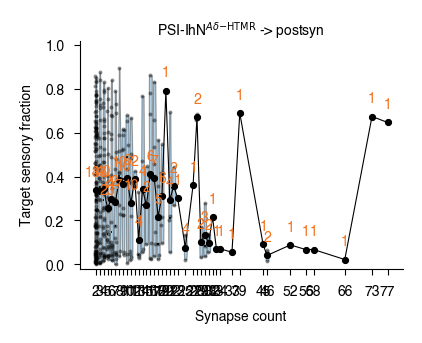

Saved: figureS11_outputs/violin_islet-chtmr__axon_pre.svg   (n plotted = 159 )


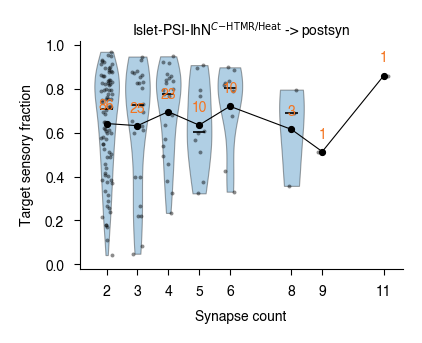

Saved: figureS11_outputs/violin_islet-cltmr__axon_pre.svg   (n plotted = 85 )


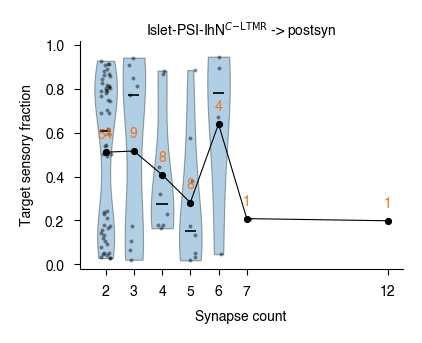

Saved: figureS11_outputs/violin_islet-adltmr__axon_pre.svg   (n plotted = 519 )


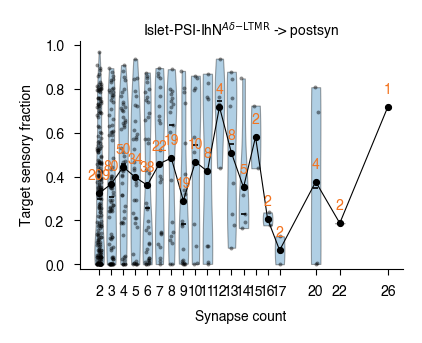

Saved: figureS11_outputs/violin_IN-abltmr__axon_pre.svg   (n plotted = 554 )


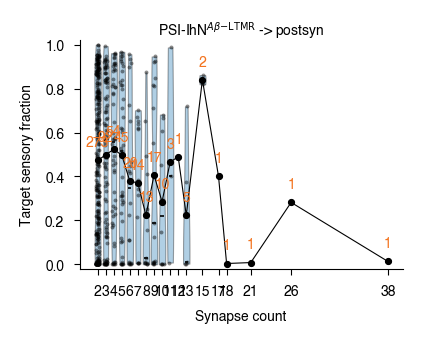

In [14]:
# ============================================================
# CELL 3: FIGURE 1 -- Violin plots (target_frac vs n_synapses), one per tag
# Uses ONLY canonical_df rows with status == "ok"
# ============================================================

MIN_N_PER_BIN = 2
JITTER = 0.18
DOT_SIZE = 2
DOT_ALPHA = 0.45
N_LABEL_COLOR = "#f37420"

# Optional: bin the long tail of n_synapses into a single "thr+" bin per tag.
# Leave empty ({}) to disable tail binning entirely.
TAIL_BIN_THRESH = {}

CM = 1 / 2.54
FIG_SIZE_IN = (5 * CM, 4 * CM)

def _apply_tail_binning(sub_df, tag, xcol="n_synapses"):
    sub_df = sub_df.copy()
    thr = TAIL_BIN_THRESH.get(tag)
    if thr is None:
        return sub_df
    sub_df[xcol] = np.where(sub_df[xcol] > thr, thr, sub_df[xcol])
    return sub_df

def _safe_basename(s):
    return "".join(c if c.isalnum() or c in ("-", "_") else "_" for c in s)

violin_ok = canonical_df[canonical_df["status"] == "ok"].dropna(subset=["n_synapses", "target_frac"]).copy()

violin_ns = {}  # tag -> total n plotted, for the cross-figure summary at the end

for tag in TAGS:
    sub = violin_ok[violin_ok["tag"] == tag][["n_synapses", "target_frac"]].copy()
    sub["n_synapses"] = sub["n_synapses"].round().astype(int)
    sub = _apply_tail_binning(sub, tag, "n_synapses")

    fig, ax = plt.subplots(figsize=FIG_SIZE_IN, dpi=200)

    if sub.empty:
        ax.text(0.5, 0.5, f"No data for {tag}", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        violin_ns[tag] = 0
    else:
        xs = np.sort(sub["n_synapses"].unique())
        data = [sub.loc[sub["n_synapses"] == x, "target_frac"].values for x in xs]
        counts = np.array([len(d) for d in data])
        keep = counts >= MIN_N_PER_BIN
        xs_keep, data_keep = xs[keep], [d for d, k in zip(data, keep) if k]

        if len(xs_keep) > 0:
            parts = ax.violinplot(data_keep, positions=xs_keep.astype(float), widths=0.8,
                                   showmeans=False, showmedians=True, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_alpha(0.35); pc.set_linewidth(0.4); pc.set_edgecolor("black")
            parts["cmedians"].set_linewidth(0.6); parts["cmedians"].set_color("black")

        rng = np.random.default_rng(0)
        for x in xs:
            y = sub.loc[sub["n_synapses"] == x, "target_frac"].values
            jitter = rng.uniform(-JITTER, JITTER, size=len(y))
            ax.scatter(np.full_like(y, x, dtype=float) + jitter, y, s=DOT_SIZE, alpha=DOT_ALPHA,
                       linewidths=0, color="black", zorder=3)

        means = sub.groupby("n_synapses")["target_frac"].mean().reindex(xs).values
        ax.plot(xs, means, marker="o", markersize=1.6, linewidth=0.4, color="black", zorder=4)

        for x in xs:
            n = int((sub["n_synapses"] == x).sum())
            y_mean = float(sub.loc[sub["n_synapses"] == x, "target_frac"].mean())
            ax.text(x, min(1.02, y_mean + 0.05), str(n), ha="center", va="bottom",
                    fontsize=5, color=N_LABEL_COLOR, zorder=5)

        thr = TAIL_BIN_THRESH.get(tag)
        xticklabels = [f"{int(thr)}+" if (thr is not None and int(x) == int(thr)) else str(int(x)) for x in xs]
        ax.set_xticks(xs); ax.set_xticklabels(xticklabels)

        violin_ns[tag] = int(len(sub))

    ax.set_title(tag_display(tag), pad=2)
    ax.set_xlabel("Synapse count")
    ax.set_ylabel("Target sensory fraction")
    ax.set_ylim(-0.02, 1.02)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.4)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.tick_params(axis="both", width=0.4, length=2)
    plt.tight_layout(pad=0.4)

    save_path = os.path.join(OUT_DIR, f"violin_{_safe_basename(tag)}__{KIND_VALUE}.svg")
    fig.savefig(save_path, format="svg")
    print("Saved:", save_path, "  (n plotted =", violin_ns[tag], ")")
    plt.show()


Saved: figureS11_outputs/ecdf_target_sensory_fraction__axon_pre.svg
  ad-htmr: n = 392
  islet-chtmr: n = 159
  islet-cltmr: n = 85
  islet-adltmr: n = 519
  IN-abltmr: n = 554


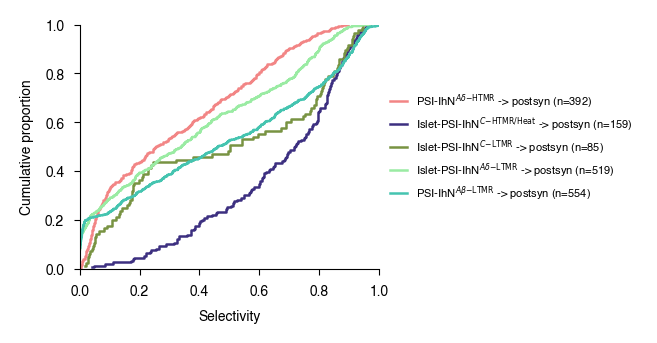

In [15]:
# ============================================================
# CELL 4: FIGURE 2 -- ECDF of target_frac, all tags on one plot
# Uses ONLY canonical_df rows with status == "ok"
# ============================================================

def ecdf(arr: np.ndarray):
    x = np.sort(arr.astype(float))
    n = len(x)
    if n == 0:
        return np.array([]), np.array([])
    y = np.arange(1, n + 1, dtype=float) / float(n)
    return x, y

CM = 1 / 2.54
fig, ax = plt.subplots(figsize=(8 * CM, 4 * CM), dpi=200)

ecdf_ns = {}
ecdf_ok = canonical_df[canonical_df["status"] == "ok"].dropna(subset=["target_frac"]).copy()

for tag in TAGS:
    arr = ecdf_ok.loc[ecdf_ok["tag"] == tag, "target_frac"].values.astype(float)
    xs, ys = ecdf(arr)
    ecdf_ns[tag] = int(len(arr))
    if len(xs) == 0:
        continue
    lab = f"{tag_display(tag)} (n={len(xs)})"
    ax.step(xs, ys, where="post", linewidth=0.9, label=lab, color=line_color_map.get(tag))

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("Selectivity")
ax.set_ylabel("Cumulative proportion")
ax.set_title("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(axis="both", width=0.4, length=2)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=4, frameon=False,
          handlelength=1.6, labelspacing=0.4, borderaxespad=0.0)
fig.subplots_adjust(right=0.72)
plt.tight_layout(pad=0.4)

save_path = os.path.join(OUT_DIR, f"ecdf_target_sensory_fraction__{KIND_VALUE}.svg")
fig.savefig(save_path, format="svg")
print("Saved:", save_path)
for tag in TAGS:
    print(f"  {tag}: n = {ecdf_ns[tag]}")
plt.show()


Saved: figureS11_outputs/ad-htmr__selectivity__axon_pre.svg


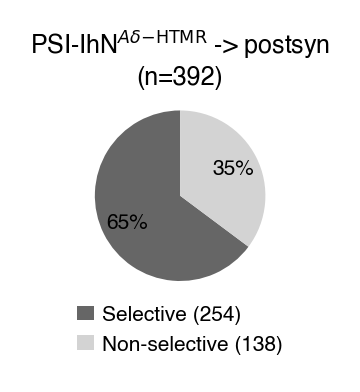

Saved: figureS11_outputs/ad-htmr__composition__axon_pre.svg


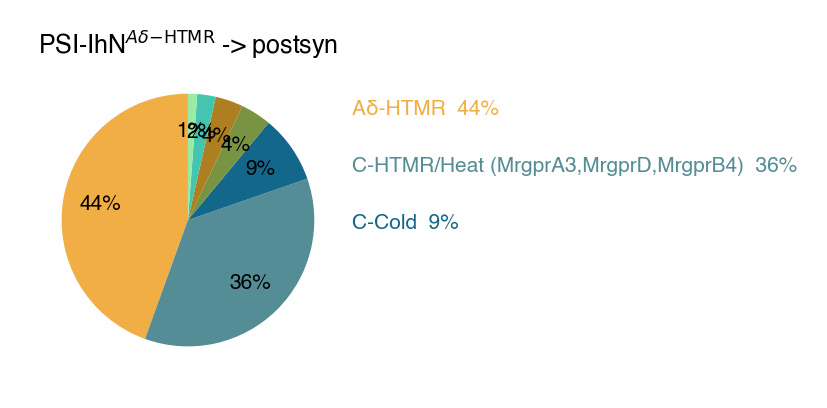

Saved: figureS11_outputs/islet-chtmr__selectivity__axon_pre.svg


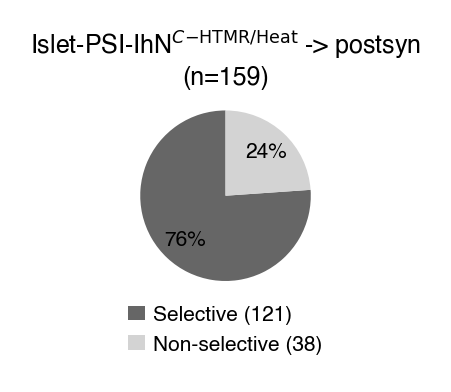

Saved: figureS11_outputs/islet-chtmr__composition__axon_pre.svg


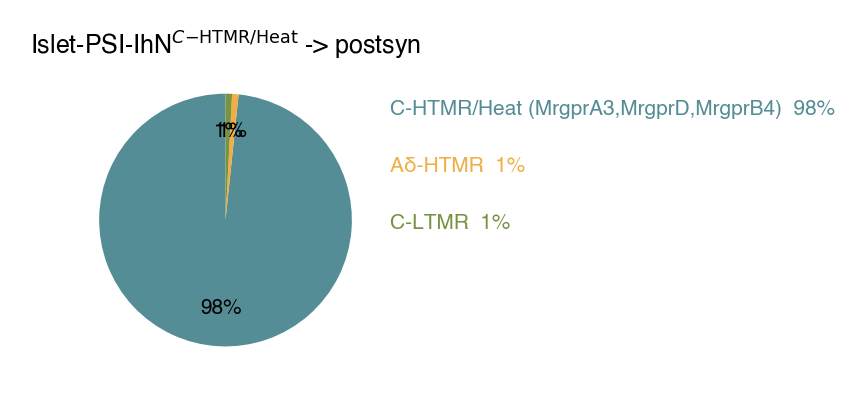

Saved: figureS11_outputs/islet-cltmr__selectivity__axon_pre.svg


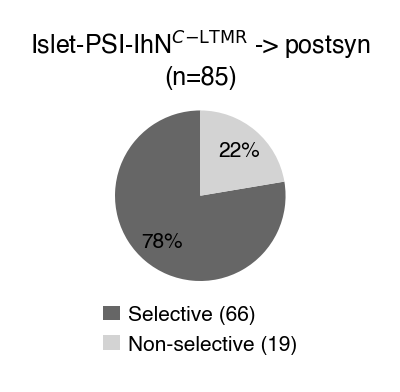

Saved: figureS11_outputs/islet-cltmr__composition__axon_pre.svg


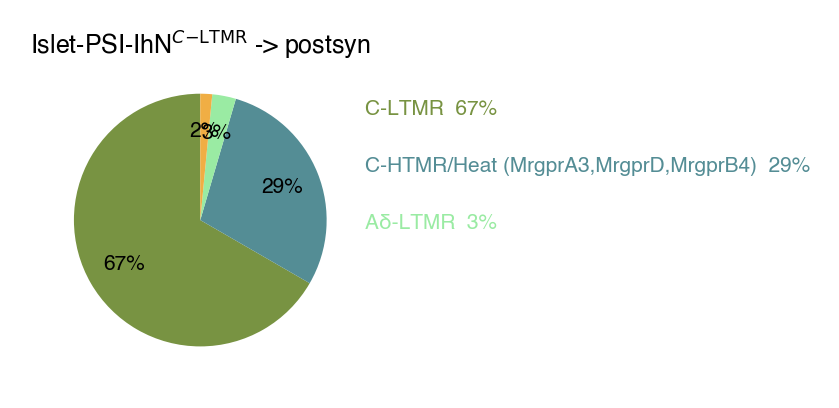

Saved: figureS11_outputs/islet-adltmr__selectivity__axon_pre.svg


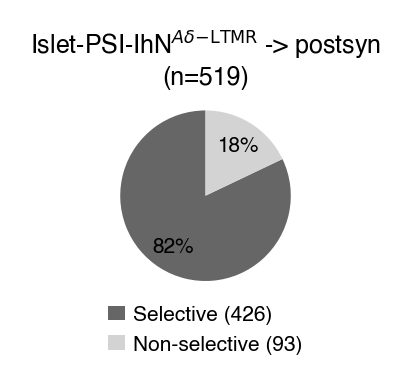

Saved: figureS11_outputs/islet-adltmr__composition__axon_pre.svg


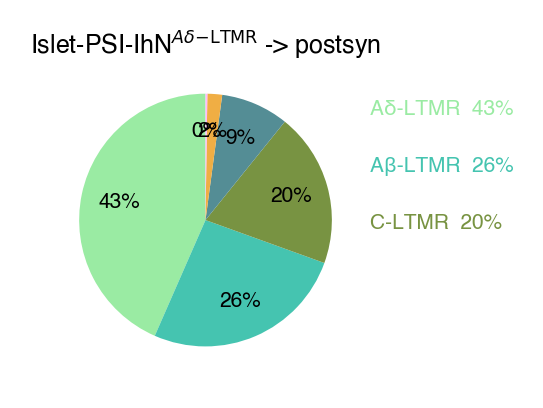

Saved: figureS11_outputs/IN-abltmr__selectivity__axon_pre.svg


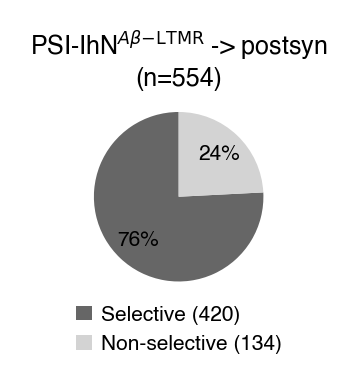

Saved: figureS11_outputs/IN-abltmr__composition__axon_pre.svg


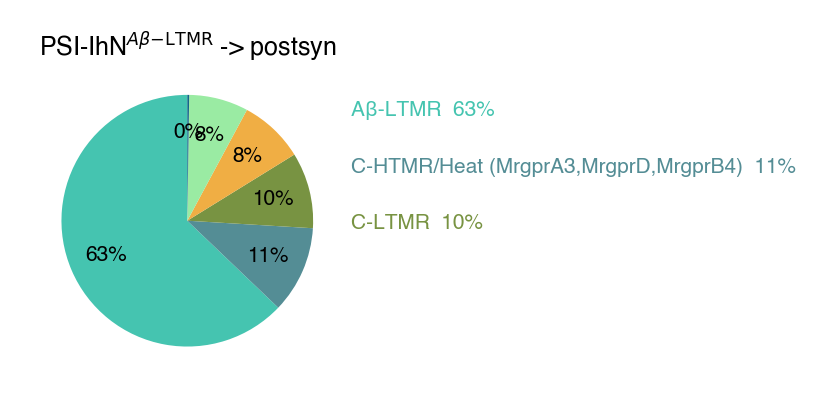

In [16]:
# ============================================================
# CELL 5: FIGURE 3 -- Pie charts (selective vs non-selective, + subtype
# breakdown among selective), one pair per tag.
# Uses ONLY canonical_df rows with status == "ok"  (SAME filter as the violin/ECDF)
# ============================================================

CM_TO_IN = 1.0 / 2.54
FIG_SIZE_CM = (4, 3)
TOPK = 3

pie_ns = {}
pie_ok = canonical_df[canonical_df["status"] == "ok"].copy()

def _outside_topk_text(ax, counts: pd.Series, topk: int, fontsize: float = 5):
    top = counts.head(topk)
    total = float(counts.sum()) if float(counts.sum()) > 0 else 1.0
    for i, (k, v) in enumerate(top.items()):
        frac = float(v) / total
        ax.text(1.02, 0.85 - i * 0.18, f"{display_name(k)}  {frac*100:.0f}%",
                transform=ax.transAxes, ha="left", va="center",
                fontsize=fontsize, color=display_color(k), clip_on=False)

for tag in TAGS:
    g = pie_ok[pie_ok["tag"] == tag]
    n_total = len(g)
    n_sel = int(g["is_selective"].sum())
    n_non = n_total - n_sel
    pie_ns[tag] = n_total

    fig_w, fig_h = FIG_SIZE_CM[0] * CM_TO_IN, FIG_SIZE_CM[1] * CM_TO_IN

    # ---- left: selective vs non-selective ----
    fig1, ax1 = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=300)
    wedges, _, autotexts = ax1.pie(
        [n_sel, n_non], startangle=90, colors=["#666666", "#d3d3d3"], labels=None,
        autopct="%1.0f%%", pctdistance=0.70, textprops={"fontsize": 5},
    )
    ax1.set_title(f"{tag_display(tag)}\n(n={n_total})", fontsize=6, pad=1)
    ax1.legend(wedges, [f"Selective ({n_sel})", f"Non-selective ({n_non})"],
               loc="lower center", bbox_to_anchor=(0.5, -0.28), fontsize=5, frameon=False,
               handlelength=0.8, handletextpad=0.4, borderaxespad=0.0)
    fig1.tight_layout(pad=0.15)
    out_left = os.path.join(OUT_DIR, f"{_safe_basename(tag)}__selectivity__{KIND_VALUE}.svg")
    fig1.savefig(out_left, format="svg")
    print("Saved:", out_left)
    plt.show()

    # ---- right: composition among selective posts ----
    fig2, ax2 = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=300)
    if n_sel > 0:
        subtype_counts = g.loc[g["is_selective"] == True, "selective_type"].astype(str).value_counts()
        colors2 = [display_color(k) for k in subtype_counts.index]
        ax2.pie(subtype_counts.values, startangle=90, colors=colors2, labels=None,
                autopct="%1.0f%%", pctdistance=0.70, textprops={"fontsize": 5})
        ax2.set_title(tag_display(tag), fontsize=6, pad=1)
        _outside_topk_text(ax2, subtype_counts, topk=TOPK)
        fig2.tight_layout(pad=0.15)
        fig2.subplots_adjust(right=0.80)
    else:
        ax2.pie([1], colors=["#d3d3d3"], labels=None)
        ax2.set_title(tag_display(tag), fontsize=6, pad=1)
        fig2.tight_layout(pad=0.15)

    out_right = os.path.join(OUT_DIR, f"{_safe_basename(tag)}__composition__{KIND_VALUE}.svg")
    fig2.savefig(out_right, format="svg")
    print("Saved:", out_right)
    plt.show()


Saved: figureS11_outputs/post_syn_sensory_composition__axon_pre_0910.svg


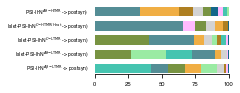

In [17]:
# ============================================================
# CELL 6: FIGURE 4 -- Stacked horizontal bar chart of sensory composition
# (one row per tag). Uses ONLY canonical_df rows with status == "ok"
# ============================================================

sensory_columns = [
    "C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR",
    "C-HTMR-Non-peptidergic", "C-LTMR", "Aδ-LTMR",
    "Aβ-LTMR", LOW_CONF_LABEL,
]

bar_ok = canonical_df[canonical_df["status"] == "ok"].copy()
bar_ns = {}

# Pull the raw per-post sensory counts back out of post_cache and sum them per tag.
rows = []
for _, r in bar_ok.iterrows():
    info = post_cache[r["post_id"]]
    row = {"tag": r["tag"]}
    row.update({ct: info["counts"].get(ct, 0) for ct in sensory_columns})
    rows.append(row)
comp_df = pd.DataFrame(rows)
for ct in sensory_columns:
    if ct not in comp_df.columns:
        comp_df[ct] = 0

grouped_counts = comp_df.groupby("tag")[sensory_columns].sum()
for tag in TAGS:
    bar_ns[tag] = int((bar_ok["tag"] == tag).sum())

CM = 1 / 2.54
fig_w, fig_h = 7 * CM, 0.7 * CM * len(TAGS)
fig, axes = plt.subplots(nrows=len(TAGS), ncols=1, figsize=(fig_w, fig_h), sharex=True)
if len(TAGS) == 1:
    axes = [axes]
fig.subplots_adjust(left=0.32, right=0.995, top=0.98, bottom=0.30, hspace=0.35)

for idx, tag in enumerate(TAGS):
    ax = axes[idx]
    if tag not in grouped_counts.index:
        ax.set_axis_off()
        continue
    row = grouped_counts.loc[tag].rename(rename_map)
    total = float(row.sum())
    if total <= 0:
        ax.set_axis_off()
        continue
    props = (row / total).sort_values(ascending=False)

    left = 0.0
    for lbl, val in props.items():
        # `lbl` is already a display name here (row was renamed via rename_map above),
        # and color_map is keyed by display names, so look it up directly.
        ax.barh(0, float(val) * 100.0, left=left, color=color_map.get(lbl, "#cccccc"),
                edgecolor="white", linewidth=0)
        left += float(val) * 100.0

    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.annotate(f"{tag_display(tag)})", xy=(0.0, 0.5), xycoords="axes fraction",
                xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                fontsize=5, fontname="Helvetica", clip_on=False)

    if idx < len(TAGS) - 1:
        ax.get_xaxis().set_visible(False)
        for sp in ax.spines.values():
            sp.set_visible(False)
    else:
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.tick_params(axis="x", labelsize=6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(True)

save_path = os.path.join(OUT_DIR, f"post_syn_sensory_composition__{KIND_VALUE}_0910.svg")
fig.savefig(save_path, format="svg")
print("Saved:", save_path)
plt.show()


In [18]:
# ============================================================
# Print the exact number behind each stacked-bar segment, per tag
# (same renaming/sorting logic used to draw the bars above)
# ============================================================
for tag in TAGS:
    if tag not in grouped_counts.index:
        print(f"\n{tag_display(tag)}  ({tag}): no data")
        continue

    row = grouped_counts.loc[tag].rename(rename_map)
    total = float(row.sum())

    print(f"\n{tag_display(tag)}  ({tag})  (n={bar_ns.get(tag, 0)} postsynaptic neurons, "
          f"{int(total)} classified partners total)")

    if total <= 0:
        print("  (no classifiable partners)")
        continue

    props = (row / total).sort_values(ascending=False)
    for lbl, frac in props.items():
        count = int(row[lbl])
        print(f"    {lbl:45s} {count:5d}  ({frac*100:5.1f}%)")


PSI-IhN$^{A\delta\mathrm{-HTMR}}$ -> postsyn  (ad-htmr)  (n=392 postsynaptic neurons, 199212 classified partners total)
    C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)          67925  ( 34.1%)
    Aδ-HTMR                                       57100  ( 28.7%)
    Peptidergic C-Nociceptors                     21436  ( 10.8%)
    Low-Confidence                                14288  (  7.2%)
    C-LTMR                                        12773  (  6.4%)
    C-Cold                                         9952  (  5.0%)
    C-HTMR/Heat (SST)                              7256  (  3.6%)
    Aβ-LTMR                                        6468  (  3.2%)
    Aδ-LTMR                                        2014  (  1.0%)

Islet-PSI-IhN$^{C\mathrm{-HTMR/Heat}}$ -> postsyn  (islet-chtmr)  (n=159 postsynaptic neurons, 62714 classified partners total)
    C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)          41350  ( 65.9%)
    C-HTMR/Heat (SST)                              5734  (  9.1%)
    C-LTMR              

In [19]:
# ============================================================
# CELL 7: Sanity check -- confirm all four figures now agree on "n" per tag
# ============================================================

summary = pd.DataFrame({
    "tag": TAGS,
    "n_canonical_ok": [int((canonical_df[(canonical_df["tag"] == t) & (canonical_df["status"] == "ok")]).shape[0]) for t in TAGS],
    "n_violin": [violin_ns.get(t, 0) for t in TAGS],
    "n_ecdf": [ecdf_ns.get(t, 0) for t in TAGS],
    "n_pie": [pie_ns.get(t, 0) for t in TAGS],
    "n_bar": [bar_ns.get(t, 0) for t in TAGS],
})
print(summary.to_string(index=False))
print()
all_match = (summary[["n_canonical_ok", "n_pie", "n_bar"]].nunique(axis=1) == 1).all()
print("n_canonical_ok == n_pie == n_bar for every tag:", bool(all_match))
print("(n_violin / n_ecdf can be slightly lower than the others only if some posts are also")
print(" missing n_synapses or target_frac for a tag not in TAG_TO_TARGET_TYPE -- otherwise they")
print(" should match too.)")


         tag  n_canonical_ok  n_violin  n_ecdf  n_pie  n_bar
     ad-htmr             392       392     392    392    392
 islet-chtmr             159       159     159    159    159
 islet-cltmr              85        85      85     85     85
islet-adltmr             519       519     519    519    519
   IN-abltmr             554       554     554    554    554

n_canonical_ok == n_pie == n_bar for every tag: True
(n_violin / n_ecdf can be slightly lower than the others only if some posts are also
 missing n_synapses or target_frac for a tag not in TAG_TO_TARGET_TYPE -- otherwise they
 should match too.)


Saved: figureS11_outputs/violin_ad-htmr__axon_pre.svg   (n plotted = 392 )


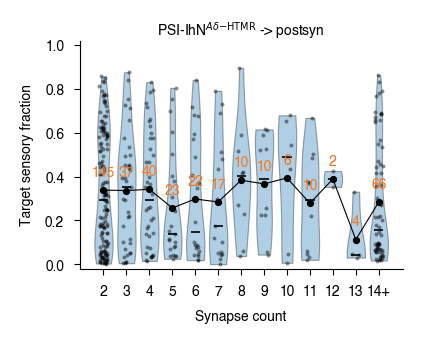

Saved: figureS11_outputs/violin_islet-chtmr__axon_pre.svg   (n plotted = 159 )


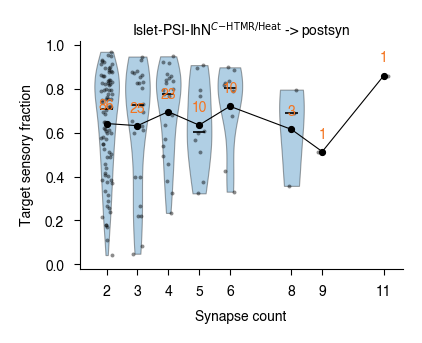

Saved: figureS11_outputs/violin_islet-cltmr__axon_pre.svg   (n plotted = 85 )


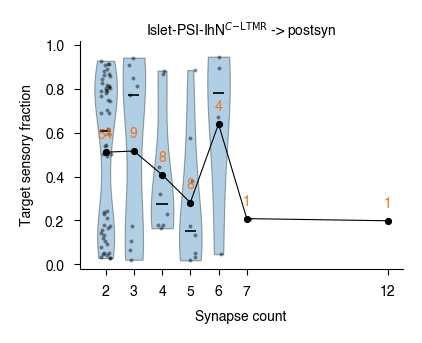

Saved: figureS11_outputs/violin_islet-adltmr__axon_pre.svg   (n plotted = 519 )


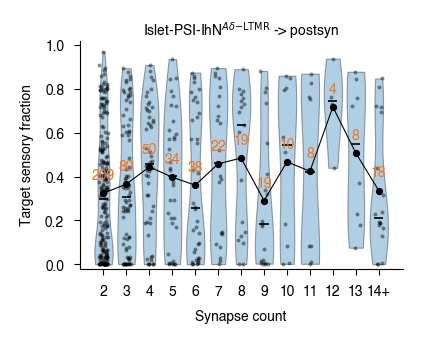

Saved: figureS11_outputs/violin_IN-abltmr__axon_pre.svg   (n plotted = 554 )


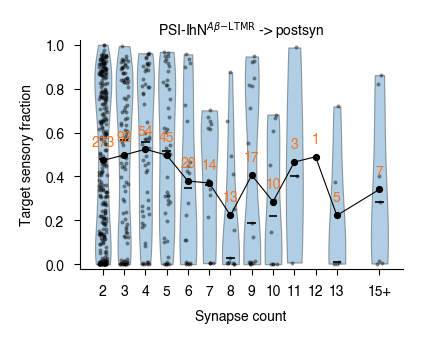

In [20]:
# ============================================================
# CELL 3: FIGURE 1 -- Violin plots (target_frac vs n_synapses), one per tag
# Uses ONLY canonical_df rows with status == "ok"
#
# CHANGED: tail binning re-enabled so any post with n_synapses >= threshold
# (per tag) is collapsed into one rightmost "thr+" bin, matching your
# reference figure. Thresholds only need to be set for tags that actually
# have a long tail -- islet-chtmr/islet-cltmr max out at 11/12 synapses in
# this dataset, so they don't need a threshold and won't get a "+" bin.
# ============================================================

MIN_N_PER_BIN = 2
JITTER = 0.18
DOT_SIZE = 2
DOT_ALPHA = 0.45
N_LABEL_COLOR = "#f37420"

# Tag -> synapse count at/above which posts get collapsed into one "thr+" bin.
# Leave a tag out of this dict (or set TAIL_BIN_THRESH = {}) to disable
# tail-binning for it / for everything.
TAIL_BIN_THRESH = {
    "ad-htmr": 14,
    "islet-adltmr": 14,
    "IN-abltmr": 15,
}

CM = 1 / 2.54
FIG_SIZE_IN = (5 * CM, 4 * CM)

def _apply_tail_binning(sub_df, tag, xcol="n_synapses"):
    sub_df = sub_df.copy()
    thr = TAIL_BIN_THRESH.get(tag)
    if thr is None:
        return sub_df
    # NOTE: ">=" so the bin exactly at threshold is folded into "thr+"
    sub_df[xcol] = np.where(sub_df[xcol] >= thr, thr, sub_df[xcol])
    return sub_df

def _safe_basename(s):
    return "".join(c if c.isalnum() or c in ("-", "_") else "_" for c in s)

violin_ok = canonical_df[canonical_df["status"] == "ok"].dropna(subset=["n_synapses", "target_frac"]).copy()

violin_ns = {}  # tag -> total n plotted, for the cross-figure summary at the end

for tag in TAGS:
    sub = violin_ok[violin_ok["tag"] == tag][["n_synapses", "target_frac"]].copy()
    sub["n_synapses"] = sub["n_synapses"].round().astype(int)
    sub = _apply_tail_binning(sub, tag, "n_synapses")

    fig, ax = plt.subplots(figsize=FIG_SIZE_IN, dpi=200)

    if sub.empty:
        ax.text(0.5, 0.5, f"No data for {tag}", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        violin_ns[tag] = 0
    else:
        xs = np.sort(sub["n_synapses"].unique())
        data = [sub.loc[sub["n_synapses"] == x, "target_frac"].values for x in xs]
        counts = np.array([len(d) for d in data])
        keep = counts >= MIN_N_PER_BIN
        xs_keep, data_keep = xs[keep], [d for d, k in zip(data, keep) if k]

        if len(xs_keep) > 0:
            parts = ax.violinplot(data_keep, positions=xs_keep.astype(float), widths=0.8,
                                   showmeans=False, showmedians=True, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_alpha(0.35); pc.set_linewidth(0.4); pc.set_edgecolor("black")
            parts["cmedians"].set_linewidth(0.6); parts["cmedians"].set_color("black")

        rng = np.random.default_rng(0)
        for x in xs:
            y = sub.loc[sub["n_synapses"] == x, "target_frac"].values
            jitter = rng.uniform(-JITTER, JITTER, size=len(y))
            ax.scatter(np.full_like(y, x, dtype=float) + jitter, y, s=DOT_SIZE, alpha=DOT_ALPHA,
                       linewidths=0, color="black", zorder=3)

        means = sub.groupby("n_synapses")["target_frac"].mean().reindex(xs).values
        ax.plot(xs, means, marker="o", markersize=1.6, linewidth=0.4, color="black", zorder=4)

        for x in xs:
            n = int((sub["n_synapses"] == x).sum())
            y_mean = float(sub.loc[sub["n_synapses"] == x, "target_frac"].mean())
            ax.text(x, min(1.02, y_mean + 0.05), str(n), ha="center", va="bottom",
                    fontsize=5, color=N_LABEL_COLOR, zorder=5)

        # x tick labels: show "thr+" only on the bin that got collapsed
        thr = TAIL_BIN_THRESH.get(tag)
        xticklabels = [f"{int(thr)}+" if (thr is not None and int(x) == int(thr)) else str(int(x)) for x in xs]
        ax.set_xticks(xs); ax.set_xticklabels(xticklabels)

        violin_ns[tag] = int(len(sub))

    ax.set_title(tag_display(tag), pad=2)
    ax.set_xlabel("Synapse count")
    ax.set_ylabel("Target sensory fraction")
    ax.set_ylim(-0.02, 1.02)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.4)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.tick_params(axis="both", width=0.4, length=2)
    plt.tight_layout(pad=0.4)

    save_path = os.path.join(OUT_DIR, f"violin_{_safe_basename(tag)}__{KIND_VALUE}.svg")
    fig.savefig(save_path, format="svg")
    print("Saved:", save_path, "  (n plotted =", violin_ns[tag], ")")
    plt.show()